# 15 - WD Rolling Intrinsic vs WD-Like LSMC

Run notebook 12 in a WD-like LSMC configuration for 1h, 2h, 3h and 4h, then compare against the published WD rolling intrinsic values.

WD-like LSMC changes relative to the normal Phase 4 LSMC:

- no DC / QR ancillary modes
- no degradation or VOM costs
- imbalance zeroed (`delta_imb_scale = 0.0`), matching WD rolling intrinsic's DA-only convention
- SS baseload noise collapsed to 10% (`ss_noise_scale = 0.1`), making chi/xi paths near-deterministic
- intraday shape noise kept at 100% (`shape_noise_scale = 1.0`), preserving the daily peak/trough spread the LSMC needs for DA arbitrage
- net dispatch grid refined to 11 levels (vs 5 in base), reducing granularity loss vs the continuous LP
- outputs are written to separate `phase4_wd_like_lsmc_*` files so normal Phase 4 results are not overwritten

In [1]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path
import json
import os
import re
import subprocess
import sys
import time

import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
PROCESSED = ROOT / 'data' / 'processed'
EXEC_DIR = PROCESSED / 'wd_like_lsmc_executed'
EXEC_DIR.mkdir(parents=True, exist_ok=True)

DURATIONS_H = [1.0, 2.0, 3.0, 4.0]
BASE_NB = ROOT / 'notebooks' / '12_phase4_method_comparison.ipynb'
RUN_EXECUTIONS = True

print(f'Root: {ROOT}')
print(f'Base notebook: {BASE_NB}')
print(f'Executed notebook dir: {EXEC_DIR}')

Root: G:\My Drive\Research\bess_project
Base notebook: G:\My Drive\Research\bess_project\notebooks\12_phase4_method_comparison.ipynb
Executed notebook dir: G:\My Drive\Research\bess_project\data\processed\wd_like_lsmc_executed


In [2]:
def _replace_once(text: str, old: str, new: str) -> str:
    if old not in text:
        raise ValueError(f'Pattern not found: {old[:80]!r}')
    return text.replace(old, new, 1)

def build_wd_like_notebook(duration_h: float) -> Path:
    nb = json.loads(BASE_NB.read_text(encoding='utf-8'))
    for cell in nb['cells']:
        if cell.get('cell_type') != 'code':
            continue
        src = ''.join(cell.get('source', []))
        if 'VALUATION_DURATION_H = float' in src and 'PHASE4_RUNS' in src:
            src = re.sub(r"PROJECT_ROOT = Path\.cwd\(\)\.parent if Path\.cwd\(\)\.name == 'notebooks' else Path\.cwd\(\)", lambda _m: f"PROJECT_ROOT = Path(r'{ROOT}')", src)
            src = re.sub(r"VALUATION_DURATION_H = float\([^\n]+", f"VALUATION_DURATION_H = float({duration_h!r})", src)
            src = _replace_once(
                src,
                "configure_asset_duration(ASSET_VAL, VALUATION_DURATION_H)\n",
                "configure_asset_duration(ASSET_VAL, VALUATION_DURATION_H)\n"
                "ASSET_VAL['vom_gbp_mwh'] = 0.0\n"
                "DEGRADATION_VAL = copy.deepcopy(DEGRADATION)\n"
                "DEGRADATION_VAL['lambda_deg_init_gbp_mwh'] = 0.0\n",
            )
            src = _replace_once(
                src,
                "PHASE4_RUN = dict(PHASE4_RUNS[PHASE4_RUN_MODE_FOR_SWEEP])\n",
                "PHASE4_RUN = dict(PHASE4_RUNS[PHASE4_RUN_MODE_FOR_SWEEP])\n"
                "PHASE4_RUN.update({\n"
                "    'dc_levels': [0.0],\n"
                "    'qr_levels': [0.0],\n"
                "    'net_levels': [-1.0, -0.8, -0.6, -0.4, -0.2, 0.0, 0.2, 0.4, 0.6, 0.8, 1.0],\n"
                "    'ss_noise_scale': 0.1,\n"
                "    'shape_noise_scale': 1.0,\n"
                "    'fwd_window_hh': 48,\n"
                "})\n"
                "print('WD-like LSMC: no ancillary, no VOM/deg, imbalance zeroed, ss_noise=0.1, shape_noise=1.0, 11 net levels')\n",
            )
        if 'bundle_check.raise_if_failed()' in src:
            src = _replace_once(
                src,
                "print(bundle_check.summary())\n",
                "print(bundle_check.summary())\n"
                "_ss = float(PHASE4_RUN.get('ss_noise_scale', 1.0))\n"
                "_sh = float(PHASE4_RUN.get('shape_noise_scale', 1.0))\n"
                "if _ss != 1.0 or _sh != 1.0:\n"
                "    _xi0 = bundle.xi[:, 0:1].copy()\n"
                "    bundle.chi[:] = (bundle.chi * _ss).astype(np.float32)\n"
                "    bundle.xi[:] = (_xi0 + (bundle.xi - _xi0) * _ss).astype(np.float32)\n"
                "    bundle.lam[:] = (bundle.lam * _sh).astype(np.float32)\n"
                "    bundle.ln_P_base[:] = (bundle.chi + bundle.xi).astype(np.float32)\n"
                "    print(f'ss_noise_scale={_ss:.2f}, shape_noise_scale={_sh:.2f}')\n",
            )
        if 'LSMC_FAST_CFG.update' in src:
            src = _replace_once(
                src,
                "    'fwd_window_hh': _fwd_window,\n})\n",
                "    'fwd_window_hh': _fwd_window,\n"
                "    'delta_imb_scale': 0.0,\n"
                "})\n",
            )
            src = src.replace("ASSET_VAL, LSMC_FAST_CFG, DEGRADATION, FINANCE,", "ASSET_VAL, LSMC_FAST_CFG, DEGRADATION_VAL, FINANCE,")
        if "'method': 'Forward simulation (LSMC)'" in src:
            src = src.replace("'method': 'Forward simulation (LSMC)'", "'method': 'WD-like LSMC'")
            src = re.sub(r"full-stack: DA\+ancillary, VOM=\{ASSET_VAL\.get\(.*?\):\.2f\} .*?/MWh, degradation cost", "WD-like: DA-only (imbalance zeroed), no ancillary, VOM=0, degradation=0", src)
        src = src.replace("'Forward simulation (LSMC)'", "'WD-like LSMC'")
        src = src.replace('\"Forward simulation (LSMC)\"', '\"WD-like LSMC\"')
        src = src.replace("phase4_method_comparison_{DURATION_LABEL}", "phase4_wd_like_lsmc_comparison_{DURATION_LABEL}")
        src = src.replace("lsmc_attribution_{DURATION_LABEL}", "wd_like_lsmc_attribution_{DURATION_LABEL}")
        cell['source'] = src.splitlines(True)
    out = EXEC_DIR / f'12_wd_like_lsmc_{duration_h:g}h.ipynb'
    out.write_text(json.dumps(nb, indent=1), encoding='utf-8')
    return out

def run_one_duration(duration_h: float) -> dict:
    csv_path = PROCESSED / f'phase4_wd_like_lsmc_comparison_{duration_h:g}h.csv'
    json_path = PROCESSED / f'phase4_wd_like_lsmc_comparison_{duration_h:g}h.json'
    if csv_path.exists() and json_path.exists():
        print(f'{duration_h:g}h already exists -> {csv_path.name}')
        return {'duration_h': duration_h, 'status': 'skipped_existing', 'elapsed_s': 0.0, 'csv': str(csv_path)}
    nb_path = build_wd_like_notebook(duration_h)
    out_path = EXEC_DIR / f'12_wd_like_lsmc_{duration_h:g}h.executed.ipynb'
    cmd = [
        sys.executable, '-m', 'jupyter', 'nbconvert',
        '--to', 'notebook', '--execute',
        '--output', str(out_path),
        str(nb_path),
    ]
    t0 = time.time()
    proc = subprocess.run(cmd, cwd=ROOT, text=True, capture_output=True)
    elapsed = time.time() - t0
    if proc.returncode != 0:
        print(proc.stderr[-3000:])
        raise RuntimeError(f'{duration_h:g}h failed rc={proc.returncode} after {elapsed/60:.1f} min')
    print(f'{duration_h:g}h done in {elapsed/60:.1f} min -> {out_path.name}')
    return {'duration_h': duration_h, 'status': 'ok', 'elapsed_s': elapsed, 'notebook': str(out_path)}

In [3]:
run_log = []
if RUN_EXECUTIONS:
    with ThreadPoolExecutor(max_workers=len(DURATIONS_H)) as ex:
        futs = {ex.submit(run_one_duration, dur): dur for dur in DURATIONS_H}
        for fut in as_completed(futs):
            run_log.append(fut.result())
    run_log.sort(key=lambda r: r['duration_h'])
else:
    print('RUN_EXECUTIONS=False; using any existing WD-like outputs on disk.')

run_log

4h done in 22.5 min -> 12_wd_like_lsmc_4h.executed.ipynb
1h done in 22.6 min -> 12_wd_like_lsmc_1h.executed.ipynb
3h done in 22.7 min -> 12_wd_like_lsmc_3h.executed.ipynb
2h done in 22.7 min -> 12_wd_like_lsmc_2h.executed.ipynb


[{'duration_h': 1.0,
  'status': 'ok',
  'elapsed_s': 1357.685877084732,
  'notebook': 'G:\\My Drive\\Research\\bess_project\\data\\processed\\wd_like_lsmc_executed\\12_wd_like_lsmc_1h.executed.ipynb'},
 {'duration_h': 2.0,
  'status': 'ok',
  'elapsed_s': 1362.9598937034607,
  'notebook': 'G:\\My Drive\\Research\\bess_project\\data\\processed\\wd_like_lsmc_executed\\12_wd_like_lsmc_2h.executed.ipynb'},
 {'duration_h': 3.0,
  'status': 'ok',
  'elapsed_s': 1362.31467795372,
  'notebook': 'G:\\My Drive\\Research\\bess_project\\data\\processed\\wd_like_lsmc_executed\\12_wd_like_lsmc_3h.executed.ipynb'},
 {'duration_h': 4.0,
  'status': 'ok',
  'elapsed_s': 1349.7190721035004,
  'notebook': 'G:\\My Drive\\Research\\bess_project\\data\\processed\\wd_like_lsmc_executed\\12_wd_like_lsmc_4h.executed.ipynb'}]

In [4]:
base = pd.read_csv(PROCESSED / 'phase4_all_durations_comparison.csv')
wd = base[base['method'].eq('WD rolling intrinsic')][[
    'duration_h', 'value_gbp_annualized_m', 'gbp_per_mw_year_k', 'p5_ann_m', 'p95_ann_m'
]].rename(columns={
    'value_gbp_annualized_m': 'wd_rolling_intrinsic_m',
    'gbp_per_mw_year_k': 'wd_gbp_per_mw_year_k',
    'p5_ann_m': 'wd_p5_m',
    'p95_ann_m': 'wd_p95_m',
})

rows = []
for dur in DURATIONS_H:
    f = PROCESSED / f'phase4_wd_like_lsmc_comparison_{dur:g}h.csv'
    if not f.exists():
        print(f'Missing WD-like LSMC output: {f}')
        continue
    df = pd.read_csv(f)
    row = df[df['method'].eq('WD-like LSMC')].iloc[0].to_dict()
    rows.append({
        'duration_h': dur,
        'wd_like_lsmc_m': row['value_gbp_annualized_m'],
        'wd_like_lsmc_gbp_per_mw_year_k': row['gbp_per_mw_year_k'],
        'wd_like_lsmc_p5_m': row['p5_ann_m'],
        'wd_like_lsmc_p95_m': row['p95_ann_m'],
        'n_paths': row['n_paths'],
        'notes': row['notes'],
    })
lsmc = pd.DataFrame(rows)
comparison = wd.merge(lsmc, on='duration_h', how='left')
comparison['lsmc_minus_wd_m'] = comparison['wd_like_lsmc_m'] - comparison['wd_rolling_intrinsic_m']
comparison['lsmc_over_wd'] = comparison['wd_like_lsmc_m'] / comparison['wd_rolling_intrinsic_m']

out_csv = PROCESSED / 'phase4_wd_rolling_vs_wd_like_lsmc.csv'
out_json = PROCESSED / 'phase4_wd_rolling_vs_wd_like_lsmc.json'
comparison.to_csv(out_csv, index=False)
comparison.to_json(out_json, orient='records', indent=2)
print(f'Saved: {out_csv}')
print(f'Saved: {out_json}')
comparison.round(3)


Saved: G:\My Drive\Research\bess_project\data\processed\phase4_wd_rolling_vs_wd_like_lsmc.csv
Saved: G:\My Drive\Research\bess_project\data\processed\phase4_wd_rolling_vs_wd_like_lsmc.json


,duration_h,wd_rolling_intrinsic_m,wd_gbp_per_mw_year_k,wd_p5_m,wd_p95_m,wd_like_lsmc_m,wd_like_lsmc_gbp_per_mw_year_k,wd_like_lsmc_p5_m,wd_like_lsmc_p95_m,n_paths,notes,lsmc_minus_wd_m,lsmc_over_wd
0,1.0,2.974,29.744,2.438,3.511,1.044,10.442,0.982,1.106,500,Non-anticipative LSMC policy on 500 out-of-sam...,-1.930,0.351
1,2.0,4.394,43.945,3.679,5.110,2.133,21.326,2.025,2.240,500,Non-anticipative LSMC policy on 500 out-of-sam...,-2.262,0.485
2,3.0,5.667,56.671,4.744,6.590,2.970,29.697,2.815,3.124,500,Non-anticipative LSMC policy on 500 out-of-sam...,-2.697,0.524
3,4.0,6.859,68.591,5.733,7.986,3.545,35.448,3.355,3.735,500,Non-anticipative LSMC policy on 500 out-of-sam...,-3.314,0.517


Saved: G:\My Drive\Research\bess_project\data\processed\phase4_wd_rolling_vs_wd_like_lsmc.png


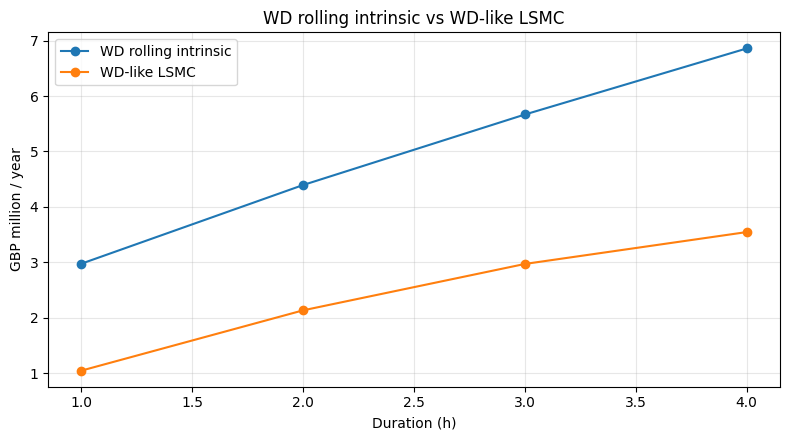

In [5]:
import matplotlib.pyplot as plt

plot_df = comparison.dropna(subset=['wd_like_lsmc_m']).copy()
if len(plot_df):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(plot_df['duration_h'], plot_df['wd_rolling_intrinsic_m'], marker='o', label='WD rolling intrinsic')
    ax.plot(plot_df['duration_h'], plot_df['wd_like_lsmc_m'], marker='o', label='WD-like LSMC')
    ax.set_xlabel('Duration (h)')
    ax.set_ylabel('GBP million / year')
    ax.set_title('WD rolling intrinsic vs WD-like LSMC')
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()
    out_png = PROCESSED / 'phase4_wd_rolling_vs_wd_like_lsmc.png'
    fig.savefig(out_png, dpi=140, bbox_inches='tight')
    print(f'Saved: {out_png}')
    plt.show()
else:
    print('No WD-like LSMC rows available to plot yet.')
